--- Statistical Significance (Chi-Square) ---
SeniorCitizen: Significant (p=1.5101e-36)
Partner: Significant (p=2.1399e-36)
Dependents: Significant (p=4.9249e-43)
InternetService: Significant (p=9.5718e-160)
OnlineSecurity: Significant (p=2.6611e-185)
TechSupport: Significant (p=1.4431e-180)
Contract: Significant (p=5.8630e-258)
PaymentMethod: Significant (p=3.6824e-140)


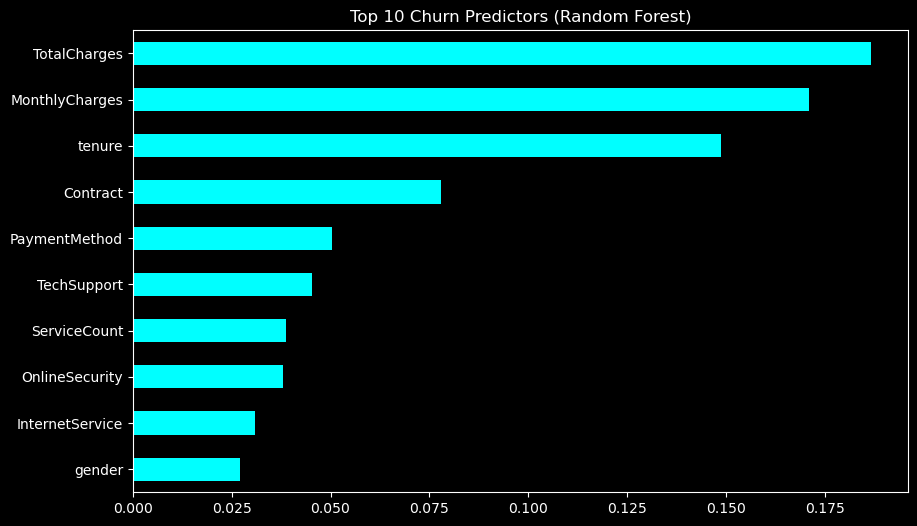

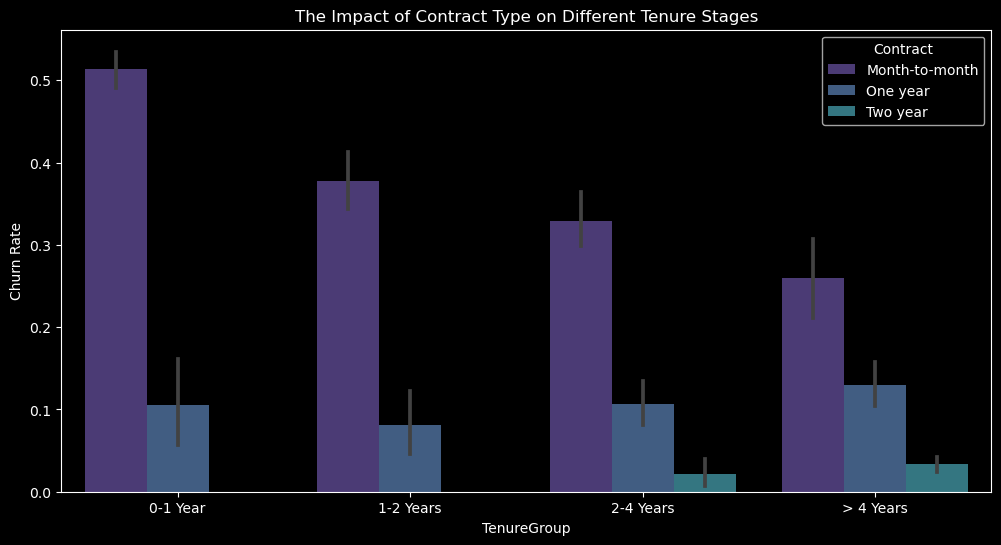

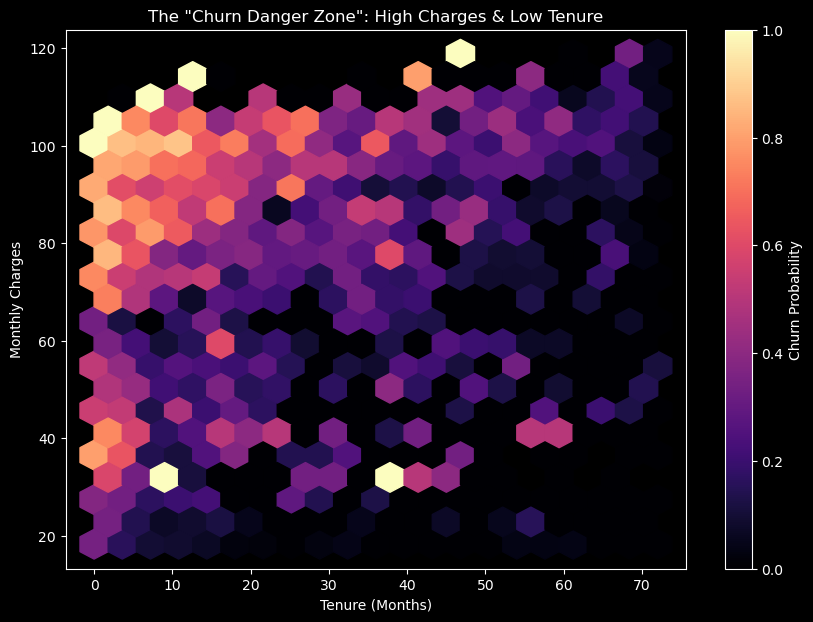

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# dark background
plt.style.use('dark_background')
sns.set_palette("viridis")

# read csv file
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# group tenure group into stages
def tenure_group(t):
    if t <= 12: return '0-1 Year'
    elif t <= 24: return '1-2 Years'
    elif t <= 48: return '2-4 Years'
    else: return '> 4 Years'
df['TenureGroup'] = df['tenure'].apply(tenure_group)

# calc service breadth
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServiceCount'] = df[service_cols].apply(lambda x: x.str.contains('Yes').sum(), axis=1)

# chi-square 
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 
                    'OnlineSecurity', 'TechSupport', 'Contract', 'PaymentMethod']
print("--- Statistical Significance (Chi-Square) ---")
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['Churn'])
    chi2, p, _, _ = chi2_contingency(contingency)
    if p < 0.05:
        print(f"{col}: Significant (p={p:.4e})")

df_model = df.drop(['customerID', 'Churn', 'Churn_Numeric', 'TenureGroup'], axis=1)
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(df_model, df['Churn_Numeric'])
importances = pd.Series(rf.feature_importances_, index=df_model.columns).sort_values(ascending=False)

# visuals
plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='cyan')
plt.title('Top 10 Churn Predictors (Random Forest)')
plt.gca().invert_yaxis()
plt.savefig('feature_importance.png')

plt.figure(figsize=(12, 6))
sns.barplot(x='TenureGroup', y='Churn_Numeric', hue='Contract', data=df, 
            order=['0-1 Year', '1-2 Years', '2-4 Years', '> 4 Years'])
plt.title('The Impact of Contract Type on Different Tenure Stages')
plt.ylabel('Churn Rate')
plt.savefig('tenure_contract_interaction.png')

# heatmap
plt.figure(figsize=(10, 7))
plt.hexbin(df['tenure'], df['MonthlyCharges'], C=df['Churn_Numeric'], gridsize=20, cmap='magma')
plt.colorbar(label='Churn Probability')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')
plt.title('The "Churn Danger Zone": High Charges & Low Tenure')
plt.savefig('hexbin_churn.png')